<a href="https://colab.research.google.com/github/josephrich98/joseph_rich_blog/blob/main/posts/genomics-vs-nlp/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genomics Is Not NLP — analysis notebook

This notebook reproduces the three figures in `main.md`. Every number is either
combinatorial (k-mer counting, $4^{-k}$), a published per-genome variation
statistic, or a real measured quantity — the mRNA-protein scatter downloads per-gene
copy numbers from Schwanhäusser et al. 2011 (Supplementary Table S1) and caches
them in `data/`. Nothing here
requires downloading a genome. The final cell verifies that every cited DOI
resolves.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

FIG = "figures"
DATA = "data"
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

NAVY, CRIMSON, STEEL, AMBER, BLACK = "#1f3b57", "#9b1d20", "#3d7ca6", "#d99a00", "#000000"
GREY = "#4d4d4d"  # Fig 1a is intentionally monochrome (no color encoding)
GENOME_BP = 3.2e9  # haploid human genome, base pairs

## Figure 1 — the corpus is nearly one document

Each panel is generated and saved on its own. Panel (a) — rendered in monochrome —
shows that two humans differ at $\sim 0.1\%$ of sites ($\pi \approx 0.001$), versus
$\sim 1.2\%$ human-chimp and essentially every token between two unrelated texts.
Panel (b) shows that within one genome, structural variants are rare as *events*
but dominate the *bases* that differ ($\sim 20$ Mb; Sudmant et al. 2015).

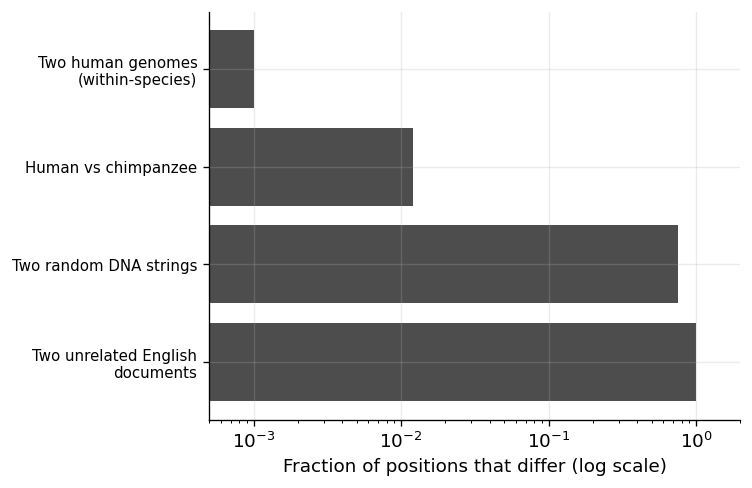

In [2]:
# Figure 1a — monochrome: two members of the species are near-duplicates
items = [
    ("Two human genomes\n(within-species)", 1.0e-3),
    ("Human vs chimpanzee", 1.2e-2),
    ("Two random DNA strings", 0.75),
    ("Two unrelated English\ndocuments", 1.0),
]
labels = [i[0] for i in items]; fracs = np.array([i[1] for i in items])
y = np.arange(len(items))[::-1]

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.barh(y, fracs, color=GREY)
ax.set_xscale("log"); ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlim(5e-4, 2.0); ax.set_xlabel("Fraction of positions that differ (log scale)")
# for yi, f in zip(y, fracs):
#     ax.text(f * 1.3, yi, f"{f:.0e}".replace("e-0", "e-"), va="center", ha="left", fontsize=9)
# ax.set_title("Two members of the species are near-duplicates")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "corpus_redundancy_a.png")); plt.show()

## Figure 2 — the proxy problem and the multiple-testing tax

Real per-gene mRNA and protein copy numbers in mouse NIH3T3 fibroblasts
(Schwanhäusser et al. 2011; $n=4{,}230$ genes; Pearson $r=0.62$ on log
abundances) — the red best-fit line has a wide scatter around it: fixing the mRNA
leaves protein spread over two to three orders of magnitude.

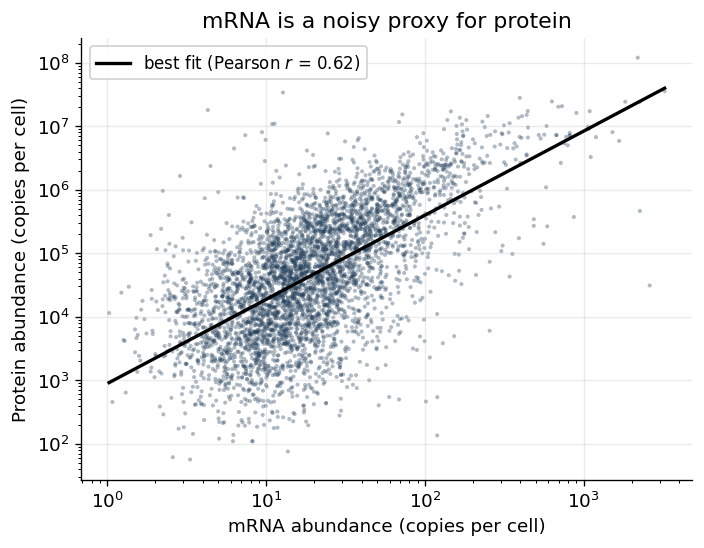

n = 4309 genes; Pearson(log10) = 0.623; slope = 1.326


In [3]:
# Figure 3a — mRNA is a noisy proxy for protein (REAL DATA)
# Per-gene mRNA & protein copy numbers in mouse NIH3T3 fibroblasts,
# Schwanhäusser et al. 2011 (Nature 473:337). Download Supplementary Table S1
# (Excel) from the publisher and cache a tidy CSV in data/.
import os, urllib.request
import pandas as pd

XLS_URL = ("https://static-content.springer.com/esm/art%3A10.1038%2Fnature10098"
           "/MediaObjects/41586_2011_BFnature10098_MOESM304_ESM.xls")
os.makedirs(DATA, exist_ok=True)
raw_xls  = os.path.join(DATA, "nature10098_S1.xls")
csv_path = os.path.join(DATA, "schwanhausser_2011_nih3t3.csv")

if not os.path.exists(csv_path):
    if not os.path.exists(raw_xls):
        print("downloading Schwanhäusser 2011 Supplementary Table S1 ...")
        req = urllib.request.Request(XLS_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(raw_xls, "wb") as fh:
            fh.write(resp.read())
    raw = pd.read_excel(raw_xls, sheet_name="Sheet1")            # needs xlrd for .xls
    col = lambda p: next(c for c in raw.columns if c.startswith(p))
    df = pd.DataFrame({
        "gene":    raw[col("Gene Names")].astype(str).str.split(";").str[0],
        "mrna":    pd.to_numeric(raw[col("mRNA copy number average")], errors="coerce"),
        "protein": pd.to_numeric(raw[col("Protein copy number average")], errors="coerce"),
    })
    df = df[(df["mrna"] > 0) & (df["protein"] > 0)].dropna()
    df.to_csv(csv_path, index=False)

df = pd.read_csv(csv_path)
lx, ly = np.log10(df["mrna"]), np.log10(df["protein"])
r, _ = pearsonr(lx, ly)
slope, intercept = np.polyfit(lx, ly, 1)          # best-fit line in log-log space

fig, ax = plt.subplots(figsize=(6.0, 4.7))
ax.scatter(df["mrna"], df["protein"], s=6, color=NAVY, alpha=0.35, edgecolors="none")
xs = np.array([lx.min(), lx.max()])
ax.plot(10**xs, 10**(intercept + slope * xs), color="BLACK", lw=2,
        label=f"best fit (Pearson $r$ = {r:.2f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("mRNA abundance (copies per cell)")
ax.set_ylabel("Protein abundance (copies per cell)")
ax.set_title("mRNA is a noisy proxy for protein")
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "proxy_scatter.png")); plt.show()
print(f"n = {len(df)} genes; Pearson(log10) = {r:.3f}; slope = {slope:.3f}")


## Figure 3 — the unit of meaning lives on a different scale

A second reason genomics is not NLP: the atomic unit differs by orders of
magnitude. In English text the token is a *word* — typically $4$-$5$ characters.
In a genome the comparable functional unit is a *gene*, whose genomic span
(exons plus introns) runs to tens of thousands of bases, with a long tail into
the megabases ($\sim 2.4\,\mathrm{Mb}$ for dystrophin). The two distributions
below are illustrative — English word lengths from a representative per-token
length distribution, gene spans from a log-normal with a human-realistic median
($\approx 24\,\mathrm{kb}$) — but the separation is the point: the densities
barely share an axis, so the linguistic intuition that a "token" is a short,
bounded string does not transfer. Note the shared $x$-axis is logarithmic.</cell id="abfd6a64">

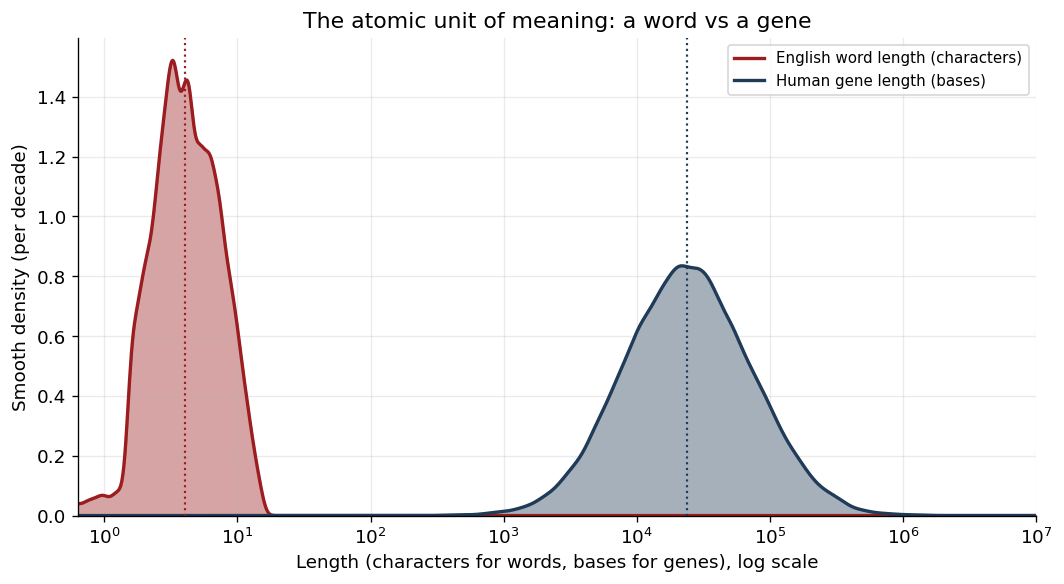

median word length = 4.1 characters; median gene span = 23,918 bases


In [4]:
from scipy.stats import gaussian_kde

rng = np.random.default_rng(11)

# English word length (per running-text token): representative length distribution
# for lengths 1..15 characters (mean ~4.7). Word length is integer-valued, so we
# spread each count across its unit-width bin (+/- 0.5) to get a smooth density
# rather than a spike at every integer.
word_len = np.arange(1, 16)
word_pmf = np.array([0.027, 0.174, 0.207, 0.157, 0.107, 0.087, 0.070,
                     0.050, 0.037, 0.028, 0.018, 0.013, 0.0085, 0.005, 0.003])
word_pmf = word_pmf / word_pmf.sum()
word_samples = rng.choice(word_len, size=40000, p=word_pmf).astype(float)
word_samples += rng.uniform(-0.5, 0.5, size=word_samples.size)
word_samples = np.clip(word_samples, 0.5, None)

# Human protein-coding gene span (genomic, exons + introns): log-normal with a
# human-realistic median (~24 kb) and a long heavy tail toward the megabases.
gene_samples = rng.lognormal(mean=np.log(24_000), sigma=1.1, size=40000)

# Smooth densities are estimated in log10 space because gene length spans many
# orders of magnitude; a linear-space KDE would be dominated by the tail.
log_words = np.log10(word_samples)
log_genes = np.log10(gene_samples)
kde_w, kde_g = gaussian_kde(log_words), gaussian_kde(log_genes)

xs = np.linspace(-0.2, 7.0, 1000)          # 10^-0.2 (~0.6) to 10^7 (10 Mb)
dw, dg = kde_w(xs), kde_g(xs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(xs, dw, color=CRIMSON, alpha=0.40)
ax.plot(xs, dw, color=CRIMSON, lw=2, label="English word length (characters)")
ax.fill_between(xs, dg, color=NAVY, alpha=0.40)
ax.plot(xs, dg, color=NAVY, lw=2, label="Human gene length (bases)")

# Median markers.
mw, mg = np.median(word_samples), np.median(gene_samples)
for med, c in [(mw, CRIMSON), (mg, NAVY)]:
    ax.axvline(np.log10(med), color=c, ls=":", lw=1.3)

ax.set_xticks(range(0, 8))
ax.set_xticklabels([f"$10^{{{t}}}$" for t in range(0, 8)])
ax.set_xlim(-0.2, 7.0)
ax.set_ylim(bottom=0)
ax.set_xlabel("Length (characters for words, bases for genes), log scale")
ax.set_ylabel("Smooth density (per decade)")
ax.set_title("The atomic unit of meaning: a word vs a gene")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "unit_length_scales.png")); plt.show()
print(f"median word length = {mw:.1f} characters; median gene span = {mg:,.0f} bases")
# print(f"ratio of medians ~ {mg/mw:,.0f}x ({np.log10(mg/mw):.1f} orders of magnitude)")</cell id="52c24997">